In [1]:
# 1 Persiapan Library

import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.linear_model import Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

In [2]:
# 2 Import Dataset

# Dataset sintetis properti untuk simulasi
rng = np.random.default_rng(42)
n = 500

df = pd.DataFrame({
    "luas_bangunan": rng.normal(120, 40, n).clip(30, None),
    "jumlah_kamar": rng.integers(1, 6, n),
    "tipe_properti": rng.choice(["Rumah", "Apartemen", "Ruko"], n),
    "kondisi_bangunan": rng.choice(["Buruk", "Sedang", "Baik", "Sangat Baik"], n)
})

df["harga"] = (
    df["luas_bangunan"] * 15 +
    df["jumlah_kamar"] * 20 +
    rng.normal(0, 50, n)
) * 1_000_000

df.head()

,luas_bangunan,jumlah_kamar,tipe_properti,kondisi_bangunan,harga
0,132.188683,3,Rumah,Baik,2.047156e+09
1,78.400636,2,Apartemen,Baik,1.232360e+09
2,150.018048,4,Rumah,Sedang,2.290644e+09
3,157.622589,1,Apartemen,Sangat Baik,2.385668e+09
4,41.958592,2,Ruko,Sedang,6.979057e+08


In [3]:
# 3 Feature Construction & Preprocessing (ColumnTransformer)

df["rasio_kamar_per_luas"] = df["jumlah_kamar"] / df["luas_bangunan"]

fitur_numerik = ["luas_bangunan", "jumlah_kamar", "rasio_kamar_per_luas"]
fitur_kategorikal = ["tipe_properti"]
fitur_ordinal = ["kondisi_bangunan"]
urutan_kondisi = [["Buruk", "Sedang", "Baik", "Sangat Baik"]]

preprocessor = ColumnTransformer(transformers=[
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), fitur_numerik),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), fitur_kategorikal),
    ("ord", OrdinalEncoder(categories=urutan_kondisi), fitur_ordinal)
])

In [4]:
# 4 Training Model (Pipeline Lengkap)

X = df.drop(columns=["harga"])
y = df["harga"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", RandomForestRegressor(n_estimators=200, random_state=42))
])

pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](5,)","['luas_bangunan','jumlah_kamar','tipe_properti','kondisi_bangunan', 'rasio_kamar_per_luas']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,5
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through

In [5]:
# 5 Evaluasi

y_pred = pipeline.predict(X_test)
print("R2 Score:", round(r2_score(y_test, y_pred), 3))

R2 Score: 0.987


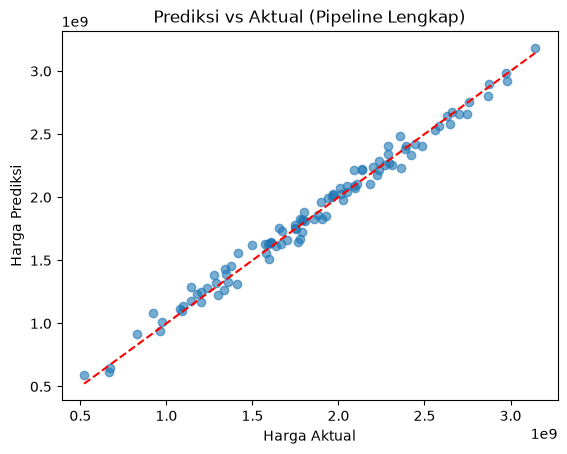

In [6]:
# 6 Visualisasi

import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred, alpha=0.6)
plt.xlabel("Harga Aktual")
plt.ylabel("Harga Prediksi")
plt.title("Prediksi vs Aktual (Pipeline Lengkap)")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()